In [4]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [2]:
electrodes = pd.read_csv("../dada_dataset/sub-001_task-baseline_duration-300.csv")['labels']#, header=None)#.to_numpy(dtype=str).flatten()
np.where(electrodes=="POz")[0][0]


37

In [12]:
with open("../pickles_osf/dataset_onset_dichotomous_test.p", "rb") as f:
    data = pickle.load(f)

channel_Y = 37
subject = "001"

In [28]:
assert data[subject,0].shape == data[subject,1].shape, "Something wrong in the data!"
Y = np.row_stack((data[subject,0][:,:,channel_Y], data[subject,1][:,:,channel_Y]))
Y /= np.std(Y)
X = np.concatenate((np.zeros(data[subject,0].shape[0]), np.ones(data[subject,1].shape[0]))).reshape(-1,1)
print(X.shape, Y.shape)

(840, 1) (840, 50)


In [3]:
# look at series of second dataset
with open("../pickles_osf/dataset_onset_dichotomous_test.p", "rb") as f:
    data = pickle.load(f)

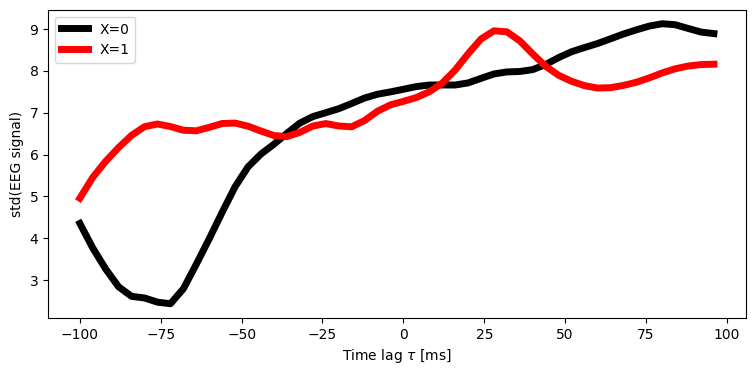

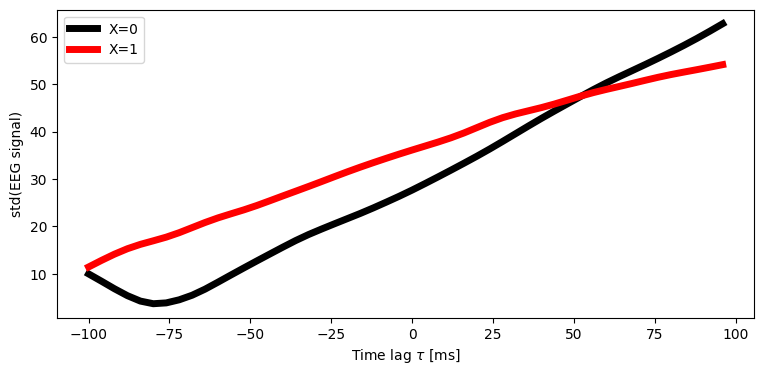

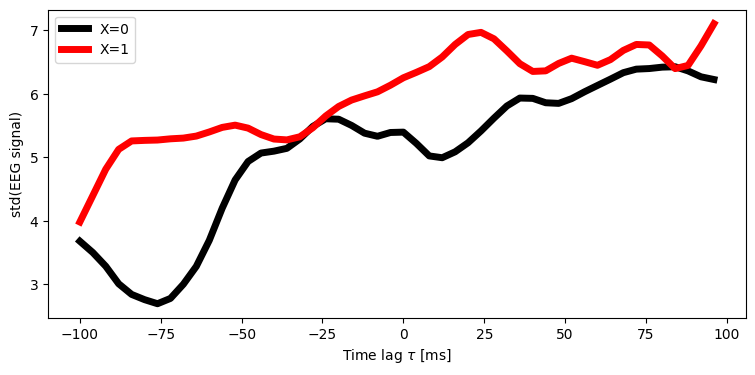

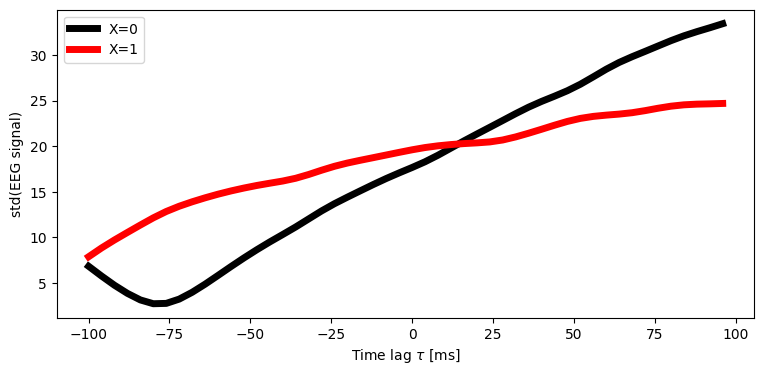

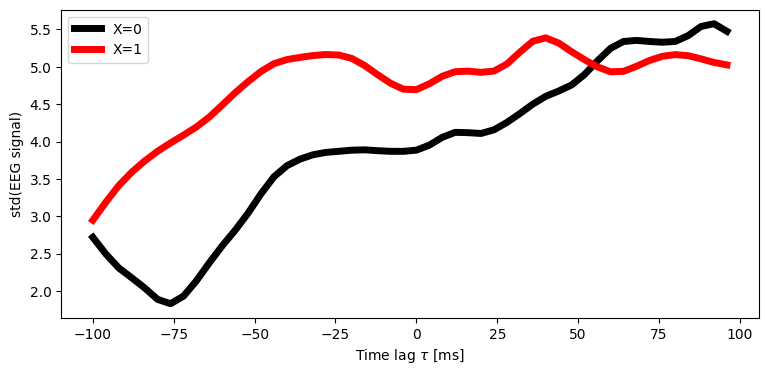

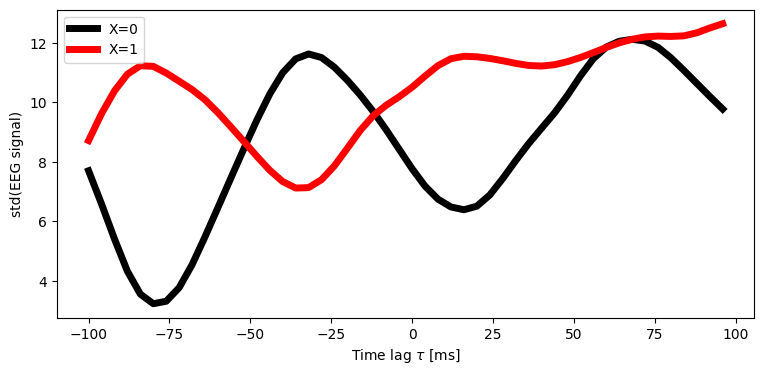

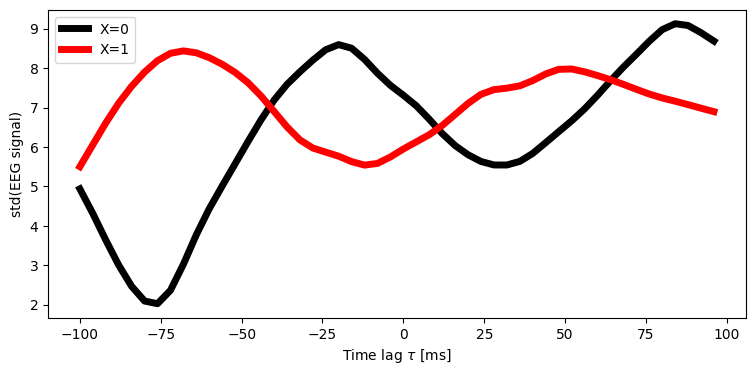

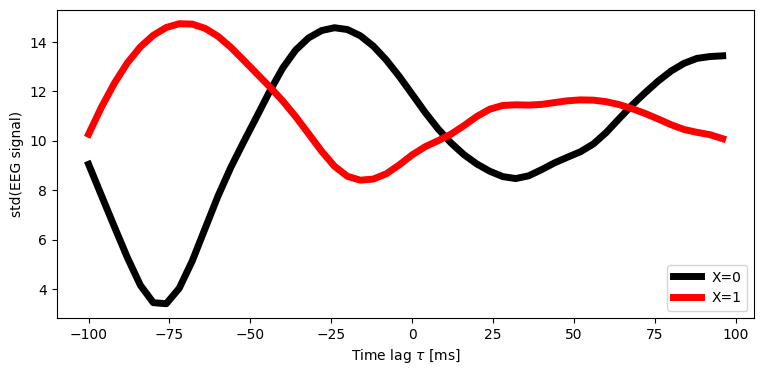

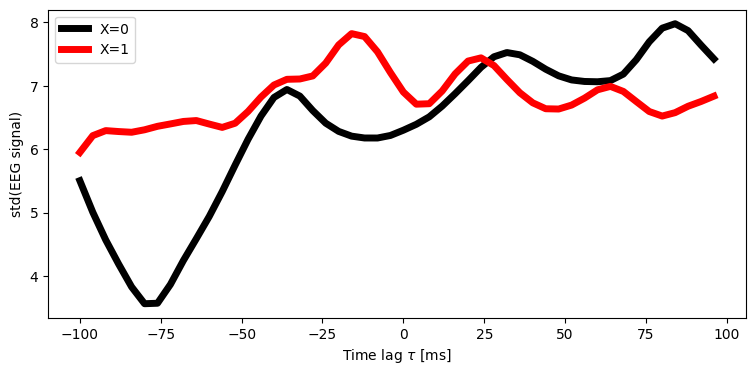

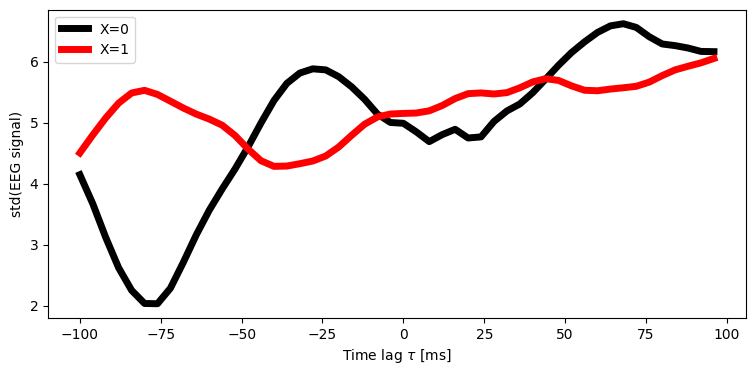

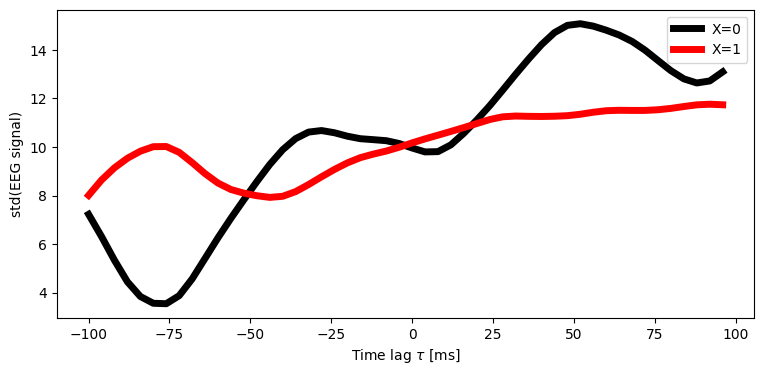

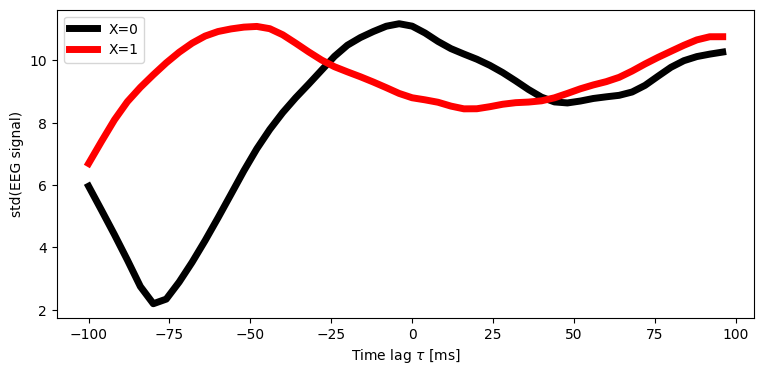

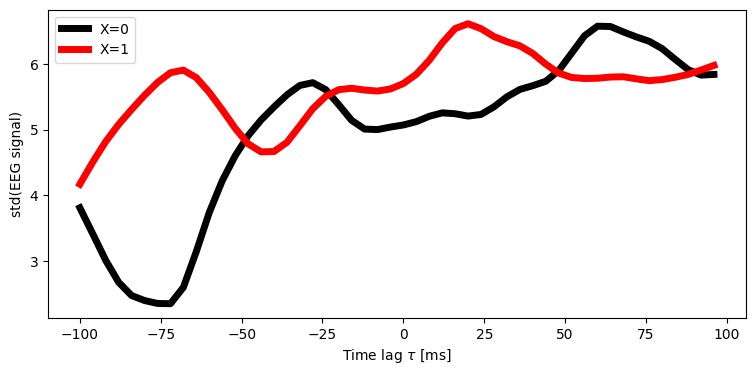

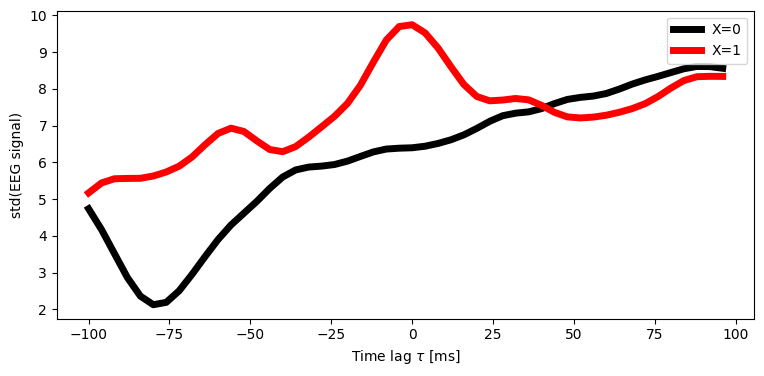

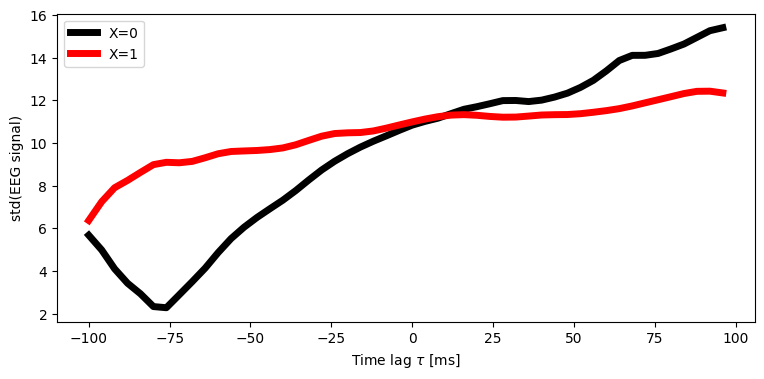

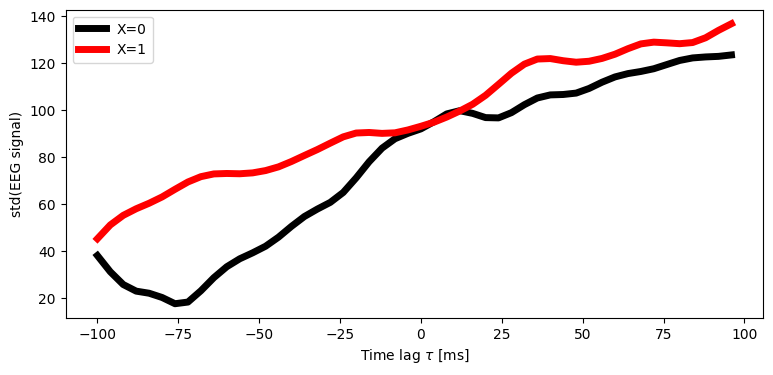

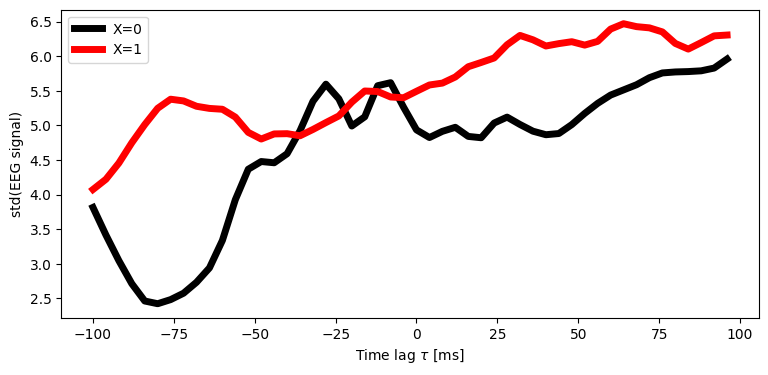

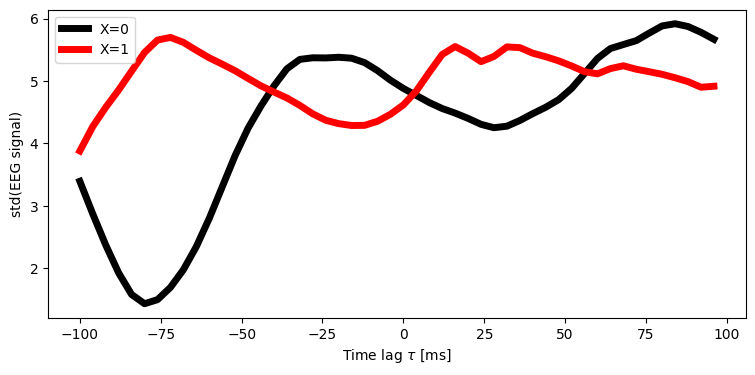

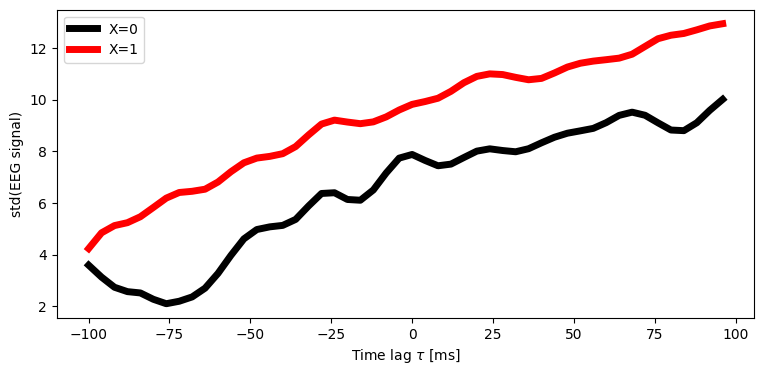

In [21]:
channel_Y = 37
subjects = (["001","002","003","004","005","006","007","008","009","010",
             "011","012","013","014","015","016","017","018","019"])
taus = np.arange(-25,25)*4

#subject = "002"
for subject in subjects:
    plt.figure(figsize=(9,4))
    #for trial in np.arange(50):
    #    plt.plot(taus, data[subject,0][trial,:,channel_Y], '-', color="black", alpha=0.1)
    #    plt.plot(taus, data[subject,1][trial,:,channel_Y], '-', color="red", alpha=0.1)
    plt.plot(taus, data[subject,0][:,:,channel_Y].std(axis=0), '-', color="black", linewidth=5, label="X=0")
    plt.plot(taus, data[subject,1][:,:,channel_Y].std(axis=0), '-', color="red",   linewidth=5, label="X=1")
    plt.legend()
    plt.xlabel("Time lag $\\tau$ [ms]")
    plt.ylabel("std(EEG signal)")
    plt.show()


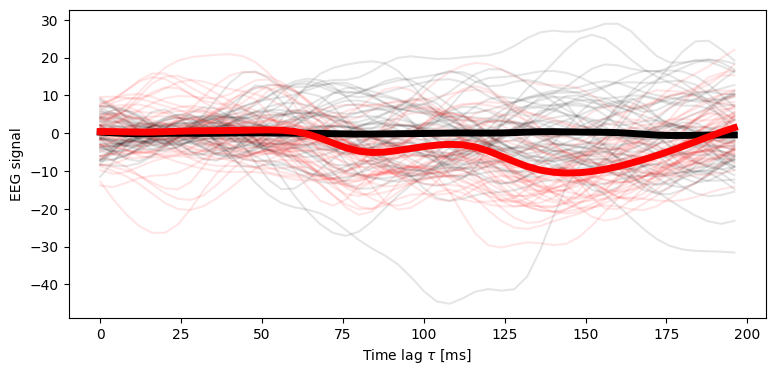

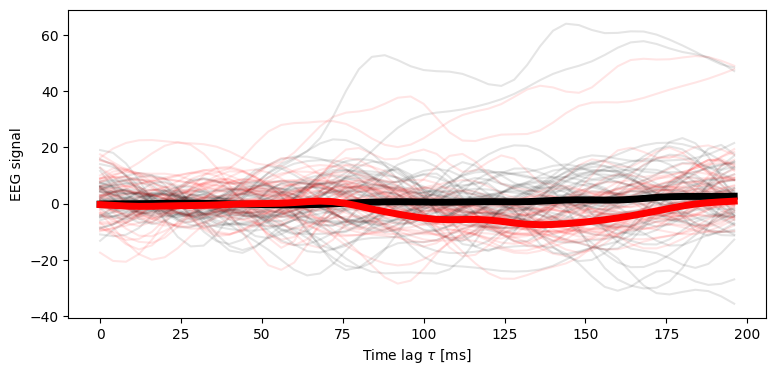

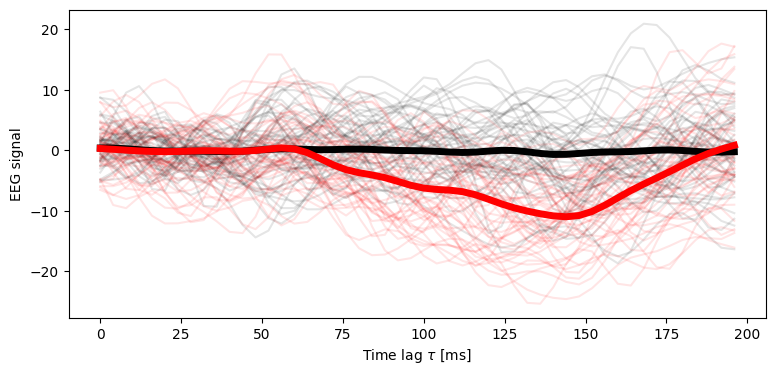

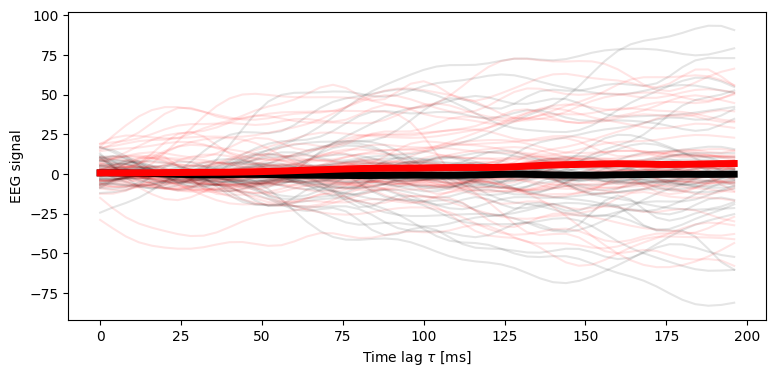

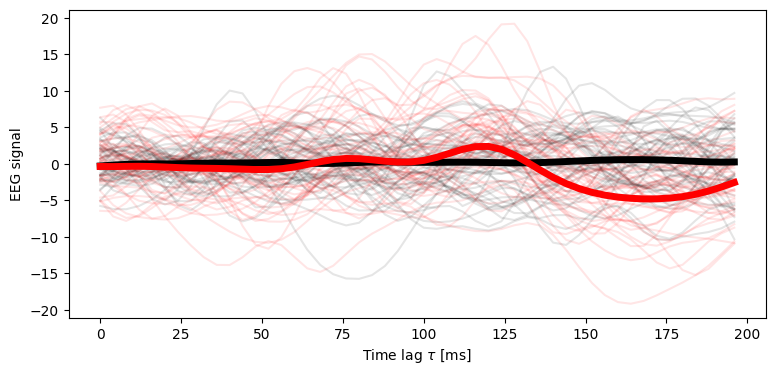

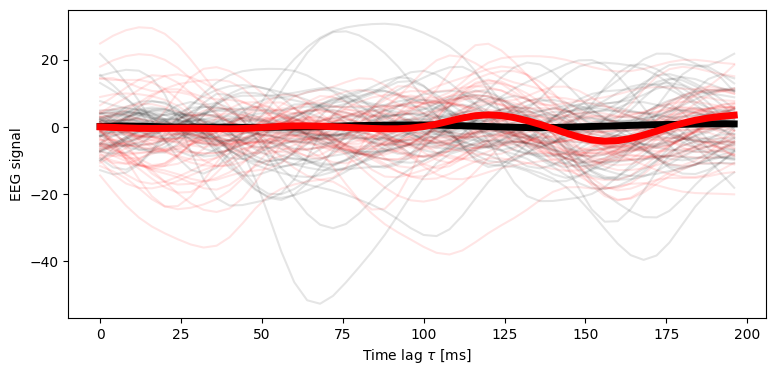

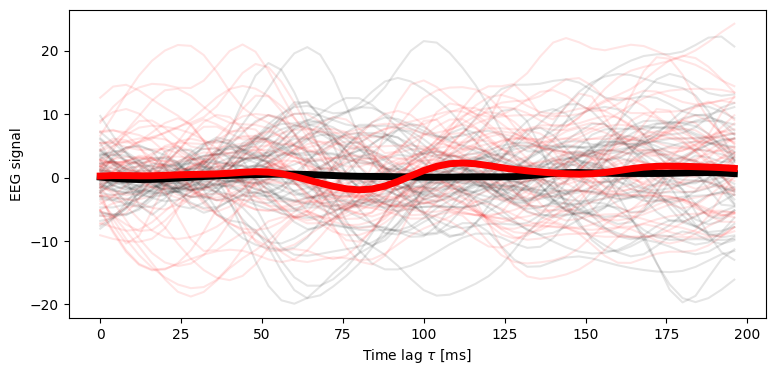

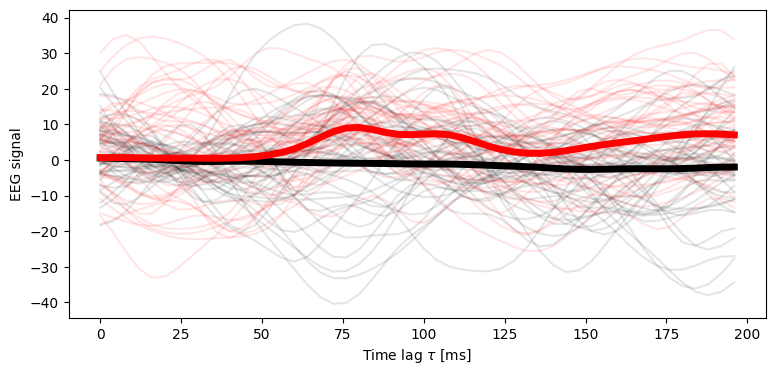

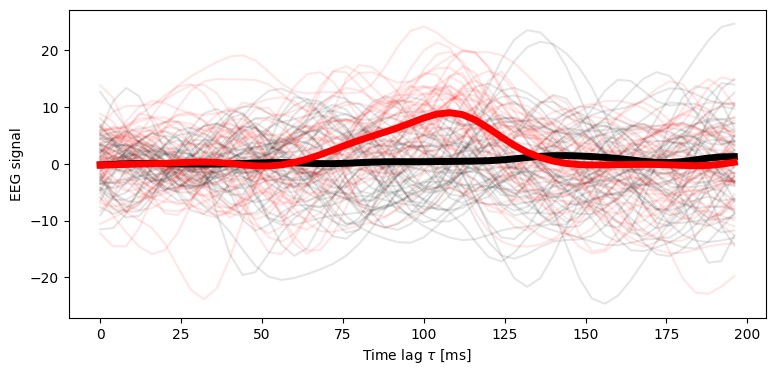

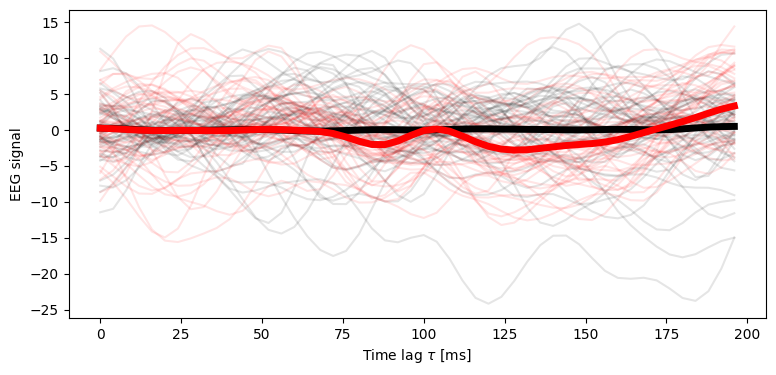

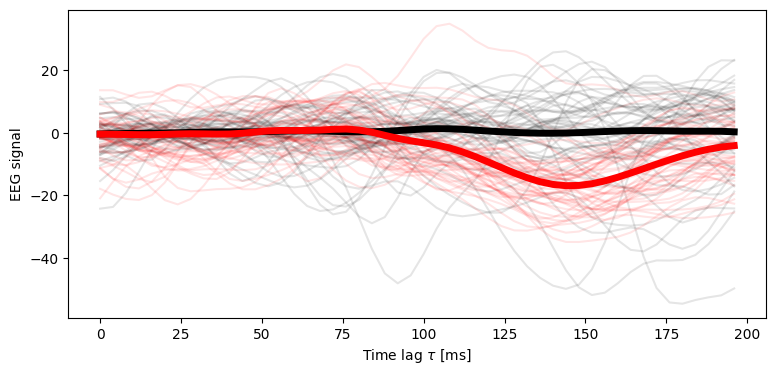

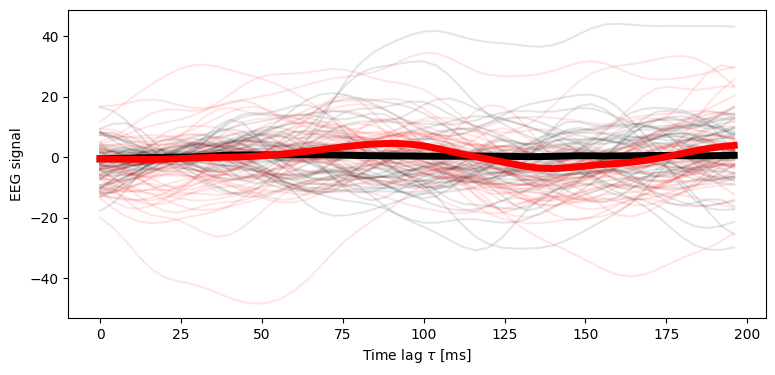

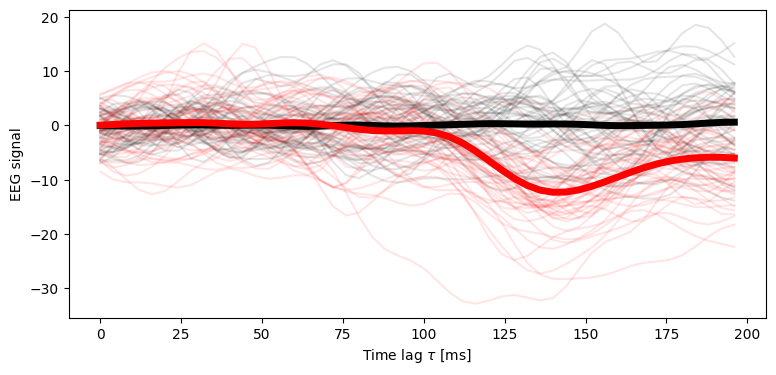

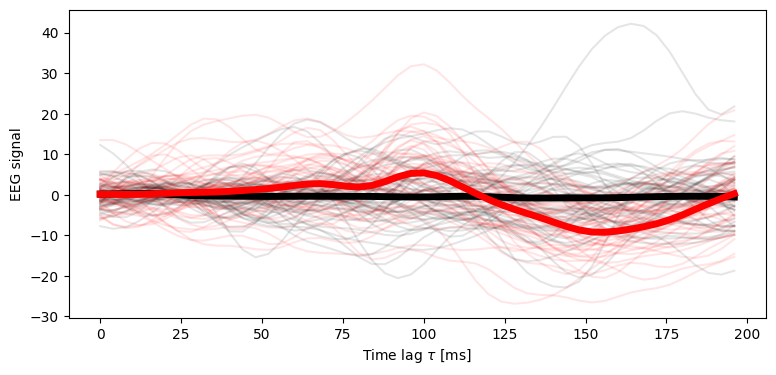

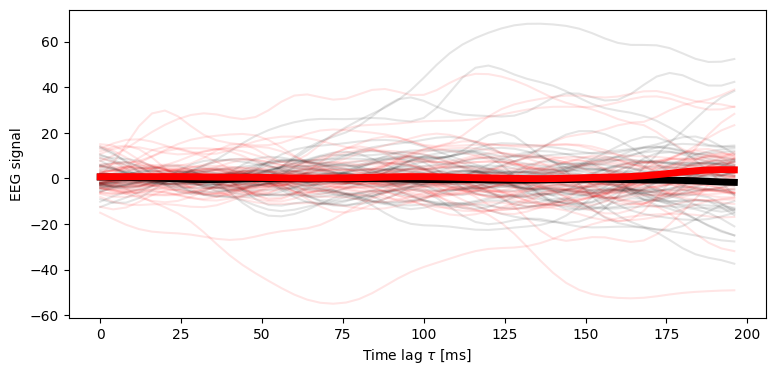

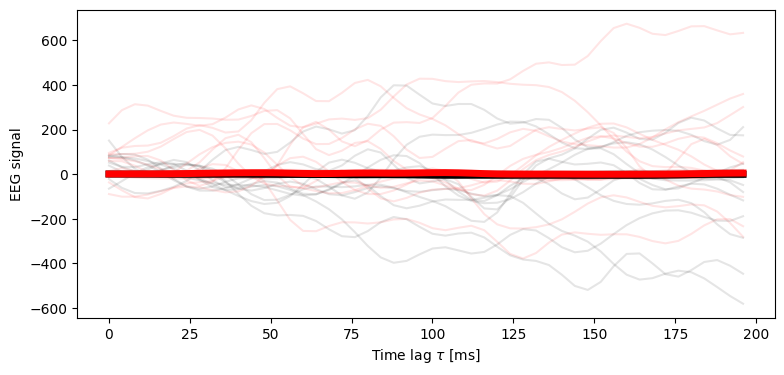

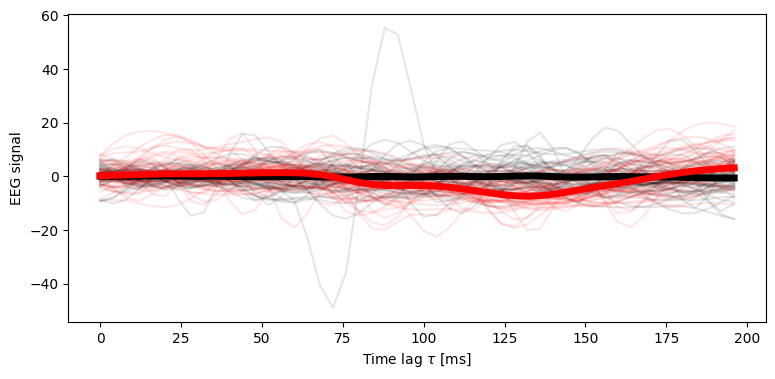

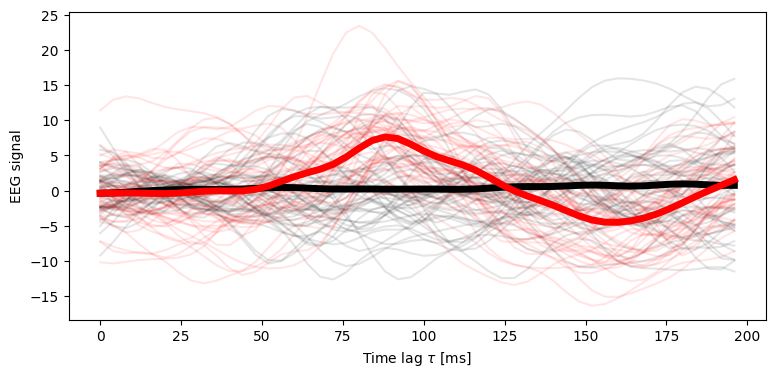

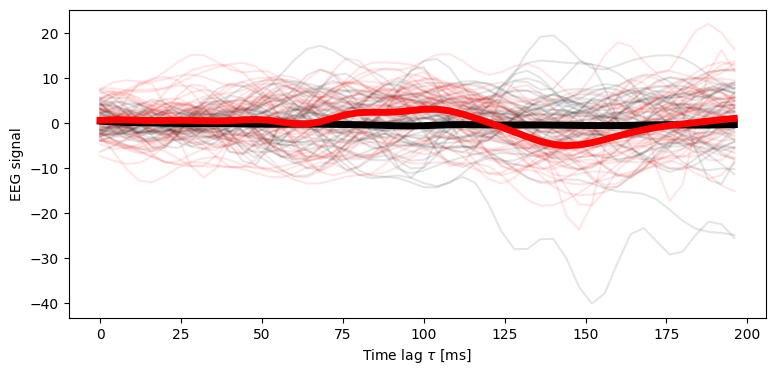

In [ ]:
channel_Y = 37
subjects = (["001","002","003","004","005","006","007","008","009","010",
             "011","012","013","014","015","016","017","018","019"])
#subject = "002"
for subject in subjects:
    plt.figure(figsize=(9,4))
    for trial in np.arange(50):
        plt.plot(4*np.arange(50), data[subject,0][trial,:,channel_Y], '-', color="black", alpha=0.1)
        plt.plot(4*np.arange(50), data[subject,1][trial,:,channel_Y], '-', color="red", alpha=0.1)
    plt.plot(4*np.arange(50), data[subject,0][:,:,channel_Y].mean(axis=0), '-', color="black", linewidth=5)
    plt.plot(4*np.arange(50), data[subject,1][:,:,channel_Y].mean(axis=0), '-', color="red",   linewidth=5)
    plt.xlabel("Time lag $\\tau$ [ms]")
    plt.ylabel("EEG signal")
    plt.show()
